In [ ]:
!pip install --upgrade pip

In [1]:
!python --version

Python 3.12.12


In [ ]:
# i.先解除安裝所有相關套件
!pip uninstall -y numpy pandas matplotlib seaborn scipy scikit-learn joblib threadpoolctl plotly Pillow scikit-image opencv-python-headless tensorflow

# ii. 清除 pip 快取
!pip cache purge

# iii. 按照正確順序重新安裝
import sys
import subprocess

packages = [
    "numpy==2.0",
    "scipy==1.14.0",
    "pandas==2.2.0",
    "matplotlib==3.8.3",
    "seaborn==0.13.2",
    "scikit-learn==1.6.0",
    "joblib==1.4.2",
    "threadpoolctl==3.5.0",
    "plotly==5.24.1",
    "Pillow==10.4.0",
    "scikit-image==0.24.0",
    "opencv-python-headless==4.9.0.80",
    "tensorflow==2.19.1"
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-deps", package])

# iv. 重新啟動核心

In [1]:
import sys
print(f"Python 版本: {sys.version}")
print(f"Python 路徑: {sys.executable}")

import numpy as np
import pandas as pd
import tensorflow as tf
import keras

print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

# 檢查 TensorFlow 是否能正常運作
print(f"TensorFlow 裝置清單:")
print(tf.config.list_physical_devices())

# 簡單測試 TensorFlow
#print("\n測試 TensorFlow 基本運算:")
#x = tf.constant([[1.0, 2.0], [3.0, 4.0]])
#print(f"矩陣:\n{x}")
#print(f"矩陣平方:\n{tf.square(x)}")

# 檢查是否可以使用 GPU/TPU
print(f"GPU 是否可用: {tf.config.list_physical_devices('GPU')}")
#print(f"TPU 是否可用: {tf.config.list_physical_devices('TPU')}")

Python 版本: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Python 路徑: /usr/bin/python3


2026-02-15 02:11:19.039055: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771121479.263876      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771121479.328438      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771121479.853547      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771121479.853591      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771121479.853594      55 computation_placer.cc:177] computation placer alr

numpy: 2.0.2
pandas: 2.2.2
TensorFlow: 2.19.0
Keras: 3.10.0
TensorFlow 裝置清單:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU 是否可用: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
!pip install pysqlite3

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/multi-class-semiconductor-wafer/Semiconductor_wafer'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# ===================================================================
# WAFER DEFECT CLASSIFICATION – EFFICIENTNET ONLY, ON-THE-FLY LOADING
# ===================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import joblib
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TerminateOnNaN
from tensorflow.keras.regularizers import l2

# For EfficientNet – only V2‑S and V2‑M are kept
try:
    from tensorflow.keras.applications import EfficientNetV2S, EfficientNetV2M
    EFFICIENTNET_AVAILABLE = True
except ImportError:
    EFFICIENTNET_AVAILABLE = False
    print("EfficientNet not available. Please install tensorflow >= 2.6.0")

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# =============================================================================
# GPU CONFIGURATION
# =============================================================================
print("Configuring GPUs for dual T4 (32 GB total)...")
gpus = tf.config.list_physical_devices('GPU')
print(f"Found {len(gpus)} GPU(s): {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ Memory growth enabled for all GPUs.")
        tf.keras.mixed_precision.set_global_policy('float32')
        print("✓ Using float32 policy.")
    except Exception as e:
        print(f"GPU configuration issue: {e}")

# Disable layout optimizer to avoid transpose errors with coordinate channels
tf.config.optimizer.set_experimental_options({'layout_optimizer': False})
print("✓ Layout optimizer disabled.")

def get_distribution_strategy():
    gpus = tf.config.list_physical_devices('GPU')
    if len(gpus) > 1:
        print(f"✓ Using MirroredStrategy with {len(gpus)} GPUs.")
        return tf.distribute.MirroredStrategy()
    else:
        print("✓ Using default single-device strategy.")
        return tf.distribute.get_strategy()

STRATEGY = get_distribution_strategy()
print(f"Strategy: {STRATEGY}")

# =============================================================================
# DISPLAY SIZE
# =============================================================================
DISPLAY_SIZE = (640, 640)

# =============================================================================
# EFFICIENTNET V2 VARIANT INPUT SIZES (only S and M)
# =============================================================================
EFFICIENTNET_V2_SIZES = {
    'S': 384,
    'M': 480
}

# =============================================================================
# ON-THE-FLY DATASET (TF.DATA) – MODIFIED FOR COORDINATE CHANNELS
# =============================================================================
class InteractiveWaferDefectLoader:
    """
    Loads wafer defect images on the fly using tf.data.Dataset.
    Stores file paths and labels, then creates datasets.
    """
    def __init__(self, kaggle_data_root, display_size=DISPLAY_SIZE):
        self.kaggle_data_root = kaggle_data_root
        self.display_size = display_size
        self.model_size = None          # will be set later based on chosen variant
        self.label_encoder = LabelEncoder()
        self.data_root_path = self._find_data_path()
        self.all_images = self._scan_all_images()
        # Prepare per-split lists of (path, label)
        self.split_paths = {}
        self.split_labels = {}
        self._build_split_lists()
        self.label_encoder_fitted = False
        self.coord_tensor = None         # will be generated when model size is set

    def _find_data_path(self):
        # First check if the root itself already contains train/valid/test
        if (os.path.exists(os.path.join(self.kaggle_data_root, 'train')) and
            os.path.exists(os.path.join(self.kaggle_data_root, 'valid')) and
            os.path.exists(os.path.join(self.kaggle_data_root, 'test'))):
            print(f"Found data directly at: {self.kaggle_data_root}")
            return self.kaggle_data_root

        # --- MODIFIED: added path with DATASETS and exact folder names as shown in the image ---
        possible_paths = [
            # Path matching the structure in the image:
            os.path.join(self.kaggle_data_root, "DATASETS", "Multi-class_Semiconductor_wafer", "Semiconductor_wafer"),
            # Keep existing fallbacks:
            os.path.join(self.kaggle_data_root, "multi-class-semiconductor-wafer", "Semiconductor_wafer"),
            os.path.join(self.kaggle_data_root, "Semiconductor_wafer"),
            self.kaggle_data_root
        ]
        for path in possible_paths:
            if os.path.exists(path):
                print(f"Found data at: {path}")
                return path
        print("Warning: Could not find data in expected locations")
        return self.kaggle_data_root

    def _scan_all_images(self):
        splits = ['train', 'valid', 'test']
        catalog = {}
        for split in splits:
            split_path = os.path.join(self.data_root_path, split)
            if not os.path.exists(split_path):
                if split == 'valid':
                    split_path = os.path.join(self.data_root_path, 'val')
                if not os.path.exists(split_path):
                    continue
            catalog[split] = {}
            categories = [d for d in os.listdir(split_path) 
                         if os.path.isdir(os.path.join(split_path, d))]
            for cat in categories:
                cat_path = os.path.join(split_path, cat)
                image_files = []
                for root, _, files in os.walk(cat_path):
                    for f in files:
                        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp')):
                            image_files.append({
                                'path': os.path.join(root, f),
                                'filename': f,
                                'category': cat,
                                'split': split
                            })
                if image_files:
                    catalog[split][cat] = image_files
        return catalog

    def _build_split_lists(self):
        """Build lists of file paths and string labels for each split."""
        for split in ['train', 'valid', 'test']:
            if split not in self.all_images:
                self.split_paths[split] = []
                self.split_labels[split] = []
                continue
            paths = []
            labels = []
            for cat, file_infos in self.all_images[split].items():
                for info in file_infos:
                    paths.append(info['path'])
                    labels.append(cat)
            self.split_paths[split] = paths
            self.split_labels[split] = labels

    def fit_label_encoder(self):
        """Fit label encoder on training labels."""
        if 'train' not in self.split_labels:
            raise ValueError("No training data available to fit encoder.")
        self.label_encoder.fit(self.split_labels['train'])
        self.label_encoder_fitted = True
        print(f"Label encoder fitted. Classes: {self.label_encoder.classes_}")

    def set_model_size(self, size):
        """Set the target input size (height and width) for the model and precompute coordinate tensor."""
        self.model_size = (size, size)
        self.coord_tensor = self._generate_coord_tensor(self.model_size)

    def _generate_coord_tensor(self, target_size):
        """Generate normalized x, y, and radial coordinate maps as a constant tensor."""
        h, w = target_size
        x = np.linspace(-1.0, 1.0, w)
        y = np.linspace(-1.0, 1.0, h)
        xx, yy = np.meshgrid(x, y)
        r = np.sqrt(xx**2 + yy**2)
        r = r / r.max()  # normalize to [0, 1]
        coord = np.stack([xx, yy, r], axis=-1).astype(np.float32)
        return tf.constant(coord)   # convert to tensor for fast concatenation

    def _preprocess_image(self, path, label, augment=False):
        """Load, resize, normalize, add coordinate channels, and optionally augment."""
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, self.model_size, method='lanczos3')
        img = tf.cast(img, tf.float32) / 255.0

        # Add coordinate channels (H, W, 3) – broadcasted constant
        coord = self.coord_tensor  # shape (H, W, 3)
        img = tf.concat([img, coord], axis=-1)  # now (H, W, 6)

        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_flip_up_down(img)
            img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
            img = tf.image.random_brightness(img, max_delta=0.1)
            img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
            img = tf.clip_by_value(img, 0.0, 1.0)

        return img, label

    def get_dataset(self, split, batch_size, augment=False, shuffle=True, drop_remainder=True):
        """
        Returns a tf.data.Dataset for the given split.
        Images are loaded and preprocessed on the fly.
        """
        if not self.label_encoder_fitted:
            raise RuntimeError("Must call fit_label_encoder() first.")
        if self.model_size is None:
            raise RuntimeError("model_size not set. Call set_model_size() first.")

        paths = self.split_paths[split]
        str_labels = self.split_labels[split]
        if len(paths) == 0:
            return None

        # Convert string labels to integer indices and then to one-hot
        int_labels = self.label_encoder.transform(str_labels)
        num_classes = len(self.label_encoder.classes_)
        one_hot_labels = keras.utils.to_categorical(int_labels, num_classes).astype(np.float32)

        # Create dataset from tensors
        dataset = tf.data.Dataset.from_tensor_slices((paths, one_hot_labels))

        if shuffle:
            dataset = dataset.shuffle(buffer_size=len(paths))

        # Map preprocessing function (parallelize)
        dataset = dataset.map(
            lambda path, label: self._preprocess_image(path, label, augment),
            num_parallel_calls=tf.data.AUTOTUNE
        )

        # Batch with drop_remainder to ensure all batches have the same size
        dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)

        return dataset

    def show_dataset_statistics(self):
        """Display detailed dataset statistics."""
        print("=" * 60)
        print("DATASET STATISTICS")
        print("=" * 60)

        categories = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 
                     'Local', 'Near-Full', 'Normal', 'Random', 'Scratch']

        stats = {}
        total_images = 0

        for split in ['train', 'valid', 'test']:
            if split in self.all_images:
                stats[split] = {}
                split_total = 0
                for category in categories:
                    if category in self.all_images[split]:
                        count = len(self.all_images[split][category])
                        stats[split][category] = count
                        split_total += count
                stats[split]['total'] = split_total
                total_images += split_total

        # Display statistics table
        print("\nDataset Distribution by Split and Category:")
        print("-" * 70)
        print(f"{'Category':<15} {'Train':<8} {'Valid':<8} {'Test':<8} {'Total':<8}")
        print("-" * 70)

        for category in categories:
            train_count = stats.get('train', {}).get(category, 0)
            valid_count = stats.get('valid', {}).get(category, 0)
            test_count = stats.get('test', {}).get(category, 0)
            category_total = train_count + valid_count + test_count
            print(f"{category:<15} {train_count:<8} {valid_count:<8} {test_count:<8} {category_total:<8}")

        print("-" * 70)
        print(f"{'Total':<15} {stats.get('train', {}).get('total', 0):<8} "
              f"{stats.get('valid', {}).get('total', 0):<8} "
              f"{stats.get('test', {}).get('total', 0):<8} {total_images:<8}")

        # Print summary statistics
        print("\n" + "=" * 60)
        print("SUMMARY STATISTICS")
        print("=" * 60)
        print(f"Total images in dataset: {total_images}")
        print(f"Training set size: {stats.get('train', {}).get('total', 0)} images")
        print(f"Validation set size: {stats.get('valid', {}).get('total', 0)} images")
        print(f"Test set size: {stats.get('test', {}).get('total', 0)} images")
        print(f"Number of defect categories: {len(categories)}")
        avg_per_category = total_images / len(categories)
        print(f"Average images per category: {avg_per_category:.1f}")
        max_count = max([stats.get(split, {}).get(cat, 0) for split in stats for cat in categories])
        min_count = min([stats.get(split, {}).get(cat, 0) for split in stats for cat in categories if stats.get(split, {}).get(cat, 0) > 0])
        imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
        if imbalance_ratio > 2:
            print(f"⚠️  Class imbalance detected: {imbalance_ratio:.1f}x difference")
        else:
            print("✓ Classes are relatively balanced")

# =============================================================================
# MODEL FACTORY – EFFICIENTNET ONLY, NOW HANDLES EXTRA COORDINATE CHANNELS
# =============================================================================
class WaferDefectModelFactory:
    def __init__(self, input_shape, num_classes):
        self.input_shape = input_shape   # (height, width, channels)
        self.num_classes = num_classes

    def _add_projection_if_needed(self, inputs):
        """
        If input has more than 3 channels, add a small projection head
        that maps to 3 channels (for the pretrained backbone).
        """
        if self.input_shape[-1] == 3:
            return inputs
        # Projection: Conv2D 3x3, 3 filters -> BN -> ReLU
        x = layers.Conv2D(3, kernel_size=3, padding='same', use_bias=False,
                          name='coord_projection_conv')(inputs)
        x = layers.BatchNormalization(name='coord_projection_bn')(x)
        x = layers.Activation('relu', name='coord_projection_relu')(x)
        return x

    def build_efficientnet_v2(self, variant='S'):
        if not EFFICIENTNET_AVAILABLE:
            raise ImportError("EfficientNet not available")
        models_map = {
            'S': EfficientNetV2S,
            'M': EfficientNetV2M
        }
        if variant not in models_map:
            print(f"Invalid variant '{variant}', defaulting to 'S'.")
            variant = 'S'
        print(f"Building EfficientNetV2-{variant} with input {self.input_shape} (pretrained weights)")

        inputs = keras.Input(shape=self.input_shape)

        # If input has extra channels, project to 3
        x = self._add_projection_if_needed(inputs)

        base = models_map[variant](
            include_top=False,
            weights='imagenet',
            input_shape=(self.input_shape[0], self.input_shape[1], 3),
            pooling='avg'
        )
        base.trainable = False

        x = base(x, training=False)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
        x = layers.BatchNormalization(epsilon=1e-3)(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
        x = layers.BatchNormalization(epsilon=1e-3)(x)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax', dtype='float32')(x)
        model = keras.Model(inputs, outputs)
        return model, base

# =============================================================================
# TRAINING FUNCTION (adapted for tf.data and partial fine-tuning)
# =============================================================================
def get_batch_size(model_type, num_gpus=1):
    """Return global batch size (conservative for 640x640 inputs)."""
    base_batch = 4   # per GPU
    return base_batch * num_gpus

class TestSetCallback(tf.keras.callbacks.Callback):
    """Evaluate test set after each epoch (works with Dataset)."""
    def __init__(self, test_dataset, verbose=0):
        super().__init__()
        self.test_dataset = test_dataset
        self.verbose = verbose
        self.test_history = {
            'test_loss': [], 'test_accuracy': [],
            'test_precision': [], 'test_recall': [], 'test_auc': []
        }

    def on_epoch_end(self, epoch, logs=None):
        try:
            test_results = self.model.evaluate(self.test_dataset, verbose=self.verbose, return_dict=True)
            for key in self.test_history:
                if key[5:] in test_results:
                    self.test_history[key].append(test_results[key[5:]])
                    logs[key] = test_results[key[5:]]
        except Exception as e:
            print(f"Warning: Test evaluation failed at epoch {epoch}: {e}")

def train_wafer_model(data_loader, output_dir='/kaggle/working/wafer_model'):
    """Train an EfficientNetV2 model (S or M) using tf.data.Dataset with coordinate channels."""
    # Fit label encoder on training set
    data_loader.fit_label_encoder()
    num_classes = len(data_loader.label_encoder.classes_)

    # Variant selection – only S and M
    print("\nEfficientNetV2 variants and their native input sizes:")
    for v, size in EFFICIENTNET_V2_SIZES.items():
        print(f"  {v}: {size}x{size}")
    choice = input("Select variant (S or M, default S): ").strip().upper()
    if choice not in EFFICIENTNET_V2_SIZES:
        print("Invalid variant, defaulting to S.")
        choice = 'S'
    variant = choice
    target_size = EFFICIENTNET_V2_SIZES[variant]

    print(f"Using EfficientNetV2-{variant} with input size {target_size}x{target_size}")

    # Create variant‑specific output directory
    variant_output_dir = os.path.join(output_dir, "EfficientNetV2", variant)
    os.makedirs(variant_output_dir, exist_ok=True)
    print(f"Saving models to: {variant_output_dir}")

    # Set the target size in the data loader (also generates coordinate tensor)
    data_loader.set_model_size(target_size)

    # Input shape: now 6 channels (RGB + 3 coordinate maps)
    input_shape = (target_size, target_size, 6)
    print(f"Input shape: {input_shape}")

    # Compute class weights from training labels
    train_labels = data_loader.split_labels['train']
    train_int_labels = data_loader.label_encoder.transform(train_labels)
    class_weights = compute_class_weight('balanced', classes=np.unique(train_int_labels), y=train_int_labels)
    class_weight_dict = {i: w for i, w in enumerate(class_weights)}
    print(f"Class weights: {class_weight_dict}")

    # Batch size
    num_gpus = len(tf.config.list_physical_devices('GPU'))
    batch_size = get_batch_size("EfficientNetV2", num_gpus)
    print(f"Global batch size: {batch_size} (across {num_gpus} GPUs)")

    # Create datasets with tf.data (drop_remainder=True to avoid uneven batches)
    train_ds = data_loader.get_dataset('train', batch_size, augment=True, shuffle=True, drop_remainder=True)
    val_ds   = data_loader.get_dataset('valid', batch_size, augment=False, shuffle=False, drop_remainder=True)
    test_ds  = data_loader.get_dataset('test',  batch_size, augment=False, shuffle=False, drop_remainder=True)

    if train_ds is None:
        raise ValueError("Training dataset is empty.")

    # Build model within strategy scope
    with STRATEGY.scope():
        model_factory = WaferDefectModelFactory(input_shape, num_classes)
        model, base_model = model_factory.build_efficientnet_v2(variant)

        optimizer = keras.optimizers.Adam(learning_rate=5e-4, clipnorm=0.5)
        model.compile(
            optimizer=optimizer,
            loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
            metrics=[
                'accuracy',
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall'),
                keras.metrics.AUC(name='auc')
            ]
        )
    model.summary()

    # ================== CALLBACKS ==================
    best_model_path = os.path.join(variant_output_dir, 'best_model.keras')
    base_callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=80, restore_best_weights=True, mode='max', verbose=1),
        ModelCheckpoint(best_model_path, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=20, min_lr=1e-7, verbose=1),
        TerminateOnNaN(),
    ]

    # Phase 1 callbacks: add test callback if test_ds exists
    phase1_callbacks = base_callbacks[:]
    if test_ds is not None:
        phase1_callbacks.append(TestSetCallback(test_ds, verbose=0))

    # Train only the head (frozen backbone + projection layers trainable)
    print("\n=== PHASE 1: Training classification head (frozen backbone) ===")
    base_model.trainable = False
    with STRATEGY.scope():
        optimizer_phase1 = keras.optimizers.Adam(learning_rate=5e-4, clipnorm=0.5)
        model.compile(optimizer=optimizer_phase1,
                      loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
                      metrics=['accuracy', 'precision', 'recall', 'auc'])
    history_phase1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=phase1_callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )

    # Phase 2: Partial fine‑tuning
    print("\n=== PHASE 2: Partial fine‑tuning (last 40 layers) ===")
    base_model.trainable = True

    # Freeze all BatchNormalization layers (keeps statistics stable)
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    # Freeze all but the last 40 layers of the base model
    total_layers = len(base_model.layers)
    for i, layer in enumerate(base_model.layers):
        if i < total_layers - 40:
            layer.trainable = False
        else:
            layer.trainable = True

    print(f"✓ Frozen first {total_layers - 40} layers, last 40 layers trainable. BN layers remain frozen.")

    with STRATEGY.scope():
        optimizer_phase2 = keras.optimizers.Adam(learning_rate=1e-4, clipnorm=0.5)
        model.compile(optimizer=optimizer_phase2,
                      loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
                      metrics=['accuracy', 'precision', 'recall', 'auc'])

    # Callbacks: add test callback if test_ds exists
    phase2_callbacks = base_callbacks[:]
    if test_ds is not None:
        test_callback_phase2 = TestSetCallback(test_ds, verbose=0)
        phase2_callbacks.insert(0, test_callback_phase2)  # place first to run after epoch

    history_phase2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=phase2_callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )

    # Attach test metrics from Phase 2 to history if available
    if test_ds is not None and 'test_callback_phase2' in locals():
        for k, v in test_callback_phase2.test_history.items():
            history_phase2.history[k] = v

    # ================== FINAL EVALUATION ==================
    print("\n=== FINAL EVALUATION ===")
    if test_ds is not None:
        test_loss, test_acc, test_prec, test_rec, test_auc = model.evaluate(test_ds, verbose=0)
        print(f"Test Accuracy: {test_acc:.4f}, Precision: {test_prec:.4f}, Recall: {test_rec:.4f}, AUC: {test_auc:.4f}")
    else:
        print("Test set not available – skipping final evaluation.")

    # Performance summary table
    print("\n" + "="*60)
    print(f"EfficientNetV2-{variant} MODEL PERFORMANCE SUMMARY")
    print("="*60)
    train_results = model.evaluate(train_ds, verbose=0, return_dict=True)
    val_results = model.evaluate(val_ds, verbose=0, return_dict=True)
    if test_ds is not None:
        test_results = model.evaluate(test_ds, verbose=0, return_dict=True)
    else:
        test_results = {m: np.nan for m in ['loss', 'accuracy', 'precision', 'recall', 'auc']}

    metrics = ['loss', 'accuracy', 'precision', 'recall', 'auc']
    summary_df = pd.DataFrame({
        'Metric': metrics,
        'Train': [train_results.get(m, np.nan) for m in metrics],
        'Validation': [val_results.get(m, np.nan) for m in metrics],
        'Test': [test_results.get(m, np.nan) for m in metrics]
    })
    print(summary_df.to_string(index=False))
    print("="*60)

    # =========================================================================
    # Plot training curves – now both phases on the same epoch axis
    # =========================================================================
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # Use the same epoch range (1 to number of epochs in each phase)
    epochs_phase1 = range(1, len(history_phase1.epoch) + 1)
    epochs_phase2 = range(1, len(history_phase2.epoch) + 1)

    def get_metric(history, metric):
        return history.history.get(metric, [])

    # Accuracy
    ax = axes[0,0]
    # Phase 1 (dashed)
    ax.plot(epochs_phase1, get_metric(history_phase1, 'accuracy'),
            linestyle='--', label='Phase 1-Train Accuracy', linewidth=2)
    ax.plot(epochs_phase1, get_metric(history_phase1, 'val_accuracy'),
            linestyle='--', label='Phase 1-Val Accuracy', linewidth=2)
    if 'test_accuracy' in history_phase1.history:
        ax.plot(epochs_phase1, get_metric(history_phase1, 'test_accuracy'),
                linestyle='--', label='Phase 1-Test Accuracy', linewidth=2, alpha=0.8)
    # Phase 2 (solid)
    ax.plot(epochs_phase2, get_metric(history_phase2, 'accuracy'),
            linestyle='-', label='Phase 2-Train Accuracy', linewidth=2)
    ax.plot(epochs_phase2, get_metric(history_phase2, 'val_accuracy'),
            linestyle='-', label='Phase 2-Val Accuracy', linewidth=2)
    if 'test_accuracy' in history_phase2.history:
        ax.plot(epochs_phase2, get_metric(history_phase2, 'test_accuracy'),
                linestyle='-', label='Phase 2-Test Accuracy', linewidth=2, alpha=0.8)
    ax.set_title(f'EfficientNetV2-{variant} Model Accuracy')
    ax.set_ylabel('Accuracy')
    ax.set_xlabel('Epoch')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

    # Loss
    ax = axes[0,1]
    ax.plot(epochs_phase1, get_metric(history_phase1, 'loss'),
            linestyle='--', label='Phase 1-Train Loss', linewidth=2)
    ax.plot(epochs_phase1, get_metric(history_phase1, 'val_loss'),
            linestyle='--', label='Phase 1-Val Loss', linewidth=2)
    if 'test_loss' in history_phase1.history:
        ax.plot(epochs_phase1, get_metric(history_phase1, 'test_loss'),
                linestyle='--', label='Phase 1-Test Loss', linewidth=2, alpha=0.8)
    ax.plot(epochs_phase2, get_metric(history_phase2, 'loss'),
            linestyle='-', label='Phase 2-Train Loss', linewidth=2)
    ax.plot(epochs_phase2, get_metric(history_phase2, 'val_loss'),
            linestyle='-', label='Phase 2-Val Loss', linewidth=2)
    if 'test_loss' in history_phase2.history:
        ax.plot(epochs_phase2, get_metric(history_phase2, 'test_loss'),
                linestyle='-', label='Phase 2-Test Loss', linewidth=2, alpha=0.8)
    ax.set_title(f'EfficientNetV2-{variant} Model Loss')
    ax.set_ylabel('Loss')
    ax.set_xlabel('Epoch')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    # Precision
    ax = axes[1,0]
    if 'precision' in history_phase1.history:
        ax.plot(epochs_phase1, get_metric(history_phase1, 'precision'),
                linestyle='--', label='Phase 1-Train Precision', linewidth=2)
    if 'val_precision' in history_phase1.history:
        ax.plot(epochs_phase1, get_metric(history_phase1, 'val_precision'),
                linestyle='--', label='Phase 1-Val Precision', linewidth=2)
    if 'test_precision' in history_phase1.history:
        ax.plot(epochs_phase1, get_metric(history_phase1, 'test_precision'),
                linestyle='--', label='Phase 1-Test Precision', linewidth=2, alpha=0.8)
    if 'precision' in history_phase2.history:
        ax.plot(epochs_phase2, get_metric(history_phase2, 'precision'),
                linestyle='-', label='Phase 2-Train Precision', linewidth=2)
    if 'val_precision' in history_phase2.history:
        ax.plot(epochs_phase2, get_metric(history_phase2, 'val_precision'),
                linestyle='-', label='Phase 2-Val Precision', linewidth=2)
    if 'test_precision' in history_phase2.history:
        ax.plot(epochs_phase2, get_metric(history_phase2, 'test_precision'),
                linestyle='-', label='Phase 2-Test Precision', linewidth=2, alpha=0.8)
    ax.set_title(f'EfficientNetV2-{variant} Model Precision')
    ax.set_ylabel('Precision')
    ax.set_xlabel('Epoch')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

    # Recall
    ax = axes[1,1]
    if 'recall' in history_phase1.history:
        ax.plot(epochs_phase1, get_metric(history_phase1, 'recall'),
                linestyle='--', label='Phase 1-Train Recall', linewidth=2)
    if 'val_recall' in history_phase1.history:
        ax.plot(epochs_phase1, get_metric(history_phase1, 'val_recall'),
                linestyle='--', label='Phase 1-Val Recall', linewidth=2)
    if 'test_recall' in history_phase1.history:
        ax.plot(epochs_phase1, get_metric(history_phase1, 'test_recall'),
                linestyle='--', label='Phase 1-Test Recall', linewidth=2, alpha=0.8)
    if 'recall' in history_phase2.history:
        ax.plot(epochs_phase2, get_metric(history_phase2, 'recall'),
                linestyle='-', label='Phase 2-Train Recall', linewidth=2)
    if 'val_recall' in history_phase2.history:
        ax.plot(epochs_phase2, get_metric(history_phase2, 'val_recall'),
                linestyle='-', label='Phase 2-Val Recall', linewidth=2)
    if 'test_recall' in history_phase2.history:
        ax.plot(epochs_phase2, get_metric(history_phase2, 'test_recall'),
                linestyle='-', label='Phase 2-Test Recall', linewidth=2, alpha=0.8)
    ax.set_title(f'EfficientNetV2-{variant} Model Recall')
    ax.set_ylabel('Recall')
    ax.set_xlabel('Epoch')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

    plt.suptitle(f'EfficientNetV2-{variant} Training History (Phase1 dashed, Phase2 solid) – {target_size}x{target_size} (Batch={batch_size}, GPUs={num_gpus})',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Save model and encoder – using variant directory
    final_model_path = os.path.join(variant_output_dir, 'final_model.keras')
    model.save(final_model_path)
    joblib.dump(data_loader.label_encoder, os.path.join(variant_output_dir, 'label_encoder.pkl'))
    with open(os.path.join(variant_output_dir, 'variant.txt'), 'w') as f:
        f.write(f"{variant}\n{target_size}")
    print(f"Model saved to {final_model_path}")
    return model, data_loader, variant, target_size

# =============================================================================
# MAIN EXECUTION (MODIFIED FOR CORRECT DATA PATH)
# =============================================================================
def main():
    print("=" * 60)
    print("WAFER DEFECT CLASSIFICATION – EFFICIENTNET V2 ONLY (S AND M)")
    print("WITH COORDINATE CHANNELS AND ANTI‑ALIAS DOWNSAMPLING")
    print("=" * 60)
    print(f"GPUs detected: {len(tf.config.list_physical_devices('GPU'))}")
    print(f"Distribution strategy: {STRATEGY}")

    # --- MODIFIED: prioritize the exact Kaggle input path ---
    data_root = None
    candidate_paths = [
        "/kaggle/input/multi-class-semiconductor-wafer",   # root as shown in the image
        "/kaggle/input",
        "./input",
        "."
    ]
    for p in candidate_paths:
        if os.path.exists(p):
            data_root = p
            print(f"Found data root at: {data_root}")
            break

    if data_root is None:
        data_root = input("Enter data path: ").strip()
    print(f"Using data root: {data_root}")

    # Initialize data loader (it will find the exact subdirectory inside)
    data_loader = InteractiveWaferDefectLoader(data_root)
    data_loader.show_dataset_statistics()

    # Mode selection (only training now)
    print("\nMODE SELECTION")
    print("1. Train new EfficientNetV2 model (S or M)")
    print("2. Load existing model (no camera simulator)")
    try:
        choice = int(input("Enter choice (1 or 2): ").strip())
    except:
        choice = 1

    if choice == 1:
        print("\n=== TRAIN NEW EFFICIENTNETV2 MODEL ===")
        model, data_loader, variant, target_size = train_wafer_model(data_loader)

    elif choice == 2:
        print("\n=== LOAD EXISTING EFFICIENTNETV2 MODEL ===")
        print("Available variants: S, M")
        variant = input("Enter variant (S or M): ").strip().upper()
        if variant not in EFFICIENTNET_V2_SIZES:
            print(f"Invalid variant, defaulting to S.")
            variant = "S"

        model_dir = os.path.join('/kaggle/working/wafer_model', "EfficientNetV2", variant)
        model_path = os.path.join(model_dir, 'best_model.keras')
        encoder_path = os.path.join(model_dir, 'label_encoder.pkl')
        variant_path = os.path.join(model_dir, 'variant.txt')

        if os.path.exists(model_path) and os.path.exists(encoder_path) and os.path.exists(variant_path):
            model = keras.models.load_model(model_path)
            data_loader.label_encoder = joblib.load(encoder_path)
            data_loader.label_encoder_fitted = True
            with open(variant_path, 'r') as f:
                saved_variant = f.readline().strip()
                target_size = int(f.readline().strip())
            data_loader.set_model_size(target_size)
            print(f"✓ Model loaded: EfficientNetV2-{saved_variant} (input size {target_size}x{target_size})")
            # Optionally evaluate on test set
            print("\nEvaluating on test set...")
            test_ds = data_loader.get_dataset('test', batch_size=8, augment=False, shuffle=False, drop_remainder=False)
            if test_ds:
                results = model.evaluate(test_ds, verbose=1)
                print(f"Test loss: {results[0]:.4f}, Test accuracy: {results[1]:.4f}")
            else:
                print("Test set not available.")
        else:
            print("Model not found. Train it first.")
    else:
        print("Invalid choice.")

if __name__ == "__main__":
    main()

2026-02-26 18:58:18.875172: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772132299.122505      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772132299.195090      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772132299.801679      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772132299.801753      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772132299.801757      55 computation_placer.cc:177] computation placer alr

Model variant: M, input size: 480x480


2026-02-26 18:58:49.829388: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded successfully
Classes: ['Center' 'Donut' 'Edge-Loc' 'Edge-Ring' 'Local' 'Near-Full' 'Normal'
 'Random' 'Scratch']
Predicted class: Near-Full (confidence: 0.9574)

Probabilities per class:
  Center: 0.0015
  Donut: 0.0013
  Edge-Loc: 0.0036
  Edge-Ring: 0.0014
  Local: 0.0040
  Near-Full: 0.9574
  Normal: 0.0066
  Random: 0.0226
  Scratch: 0.0016


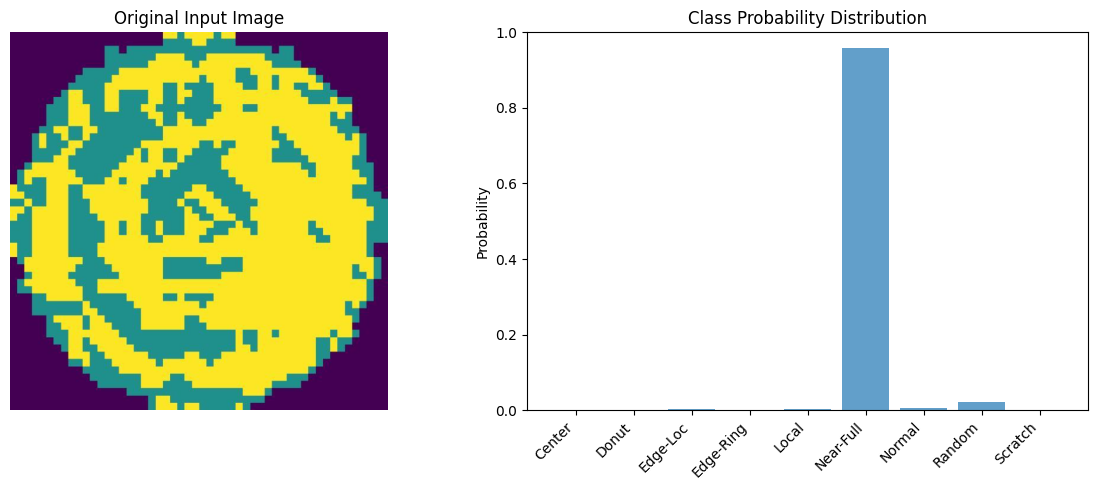

In [1]:
import os
import numpy as np
import joblib
import tensorflow as tf
from tensorflow import keras
from PIL import Image
import matplotlib.pyplot as plt   # <-- ADDED for plotting

# =============================================================================
# 1. Load model, label encoder, and variant information
# =============================================================================
model_path = '/kaggle/input/models/chenkc064/efficientnetv2-s/other/s/3/best_model.keras'          # Please modify the actual path
encoder_path = '/kaggle/input/models/chenkc064/efficientnetv2-s/other/s/3/label_encoder.pkl'       # Please modify the actual path
variant_path = '/kaggle/input/models/chenkc064/efficientnetv2-s/other/s/3/variant.txt'             # Please modify the actual path

# Read input size
with open(variant_path, 'r') as f:
    variant = f.readline().strip()
    target_size = int(f.readline().strip())
print(f"Model variant: {variant}, input size: {target_size}x{target_size}")

# Load model
model = keras.models.load_model(model_path)
print("Model loaded successfully")

# Load label encoder
label_encoder = joblib.load(encoder_path)
classes = label_encoder.classes_
print(f"Classes: {classes}")

# =============================================================================
# 2. Define preprocessing function (exactly the same as during training)
# =============================================================================
def preprocess_image(image_path, target_size):
    """
    Read an image and apply the same preprocessing as during training:
    - Decode, resize (Lanczos)
    - Normalize to [0, 1]
    - Generate coordinate channels (x, y, r) and concatenate
    """
    # Read image (supports common formats)
    img = Image.open(image_path).convert('RGB')
    img = img.resize((target_size, target_size), Image.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0   # (H, W, 3)

    # Generate coordinate channels (x, y, r)
    h, w = target_size, target_size
    x = np.linspace(-1.0, 1.0, w)
    y = np.linspace(-1.0, 1.0, h)
    xx, yy = np.meshgrid(x, y)
    r = np.sqrt(xx**2 + yy**2)
    r = r / r.max()  # normalize to [0, 1]

    coord = np.stack([xx, yy, r], axis=-1).astype(np.float32)  # (H, W, 3)

    # Concatenate image and coordinate channels => (H, W, 6)
    input_array = np.concatenate([img_array, coord], axis=-1)

    # Add batch dimension => (1, H, W, 6)
    input_array = np.expand_dims(input_array, axis=0)
    return input_array

# =============================================================================
# 3. Perform prediction
# =============================================================================
image_path = '/kaggle/input/multi-class-semiconductor-wafer/Semiconductor_wafer/test/Random/image_Random_33441_png_jpg.rf.a18de113c7c989cf9f963184113c8b29.jpg'   # Please modify to the actual image path

# Preprocess
input_tensor = preprocess_image(image_path, target_size)

# Predict
predictions = model.predict(input_tensor, verbose=0)   # shape: (1, num_classes)

# Get index of the class with highest probability
pred_class_idx = np.argmax(predictions[0])
pred_class_name = classes[pred_class_idx]
confidence = predictions[0][pred_class_idx]

print(f"Predicted class: {pred_class_name} (confidence: {confidence:.4f})")

# Optional: display probabilities for all classes
print("\nProbabilities per class:")
for cls, prob in zip(classes, predictions[0]):
    print(f"  {cls}: {prob:.4f}")

# =============================================================================
# 4. Visualization: original image and probability distribution
# =============================================================================
# Load original image for display (without preprocessing)
original_img = Image.open(image_path)
plt.figure(figsize=(12, 5))

# Subplot 1: Original image
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original Input Image")
plt.axis('off')

# Subplot 2: Probability bar chart
plt.subplot(1, 2, 2)
y_pos = np.arange(len(classes))
plt.bar(y_pos, predictions[0], align='center', alpha=0.7)
plt.xticks(y_pos, classes, rotation=45, ha='right')
plt.ylabel('Probability')
plt.title('Class Probability Distribution')
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

In [2]:
# =============================================================================
# CLASS-WISE FEATURE EXTRACTION + OUTLIER DETECTION + SQLITE DATABASE
# (Per-class PCA + Per-class Isolation Forest)
# =============================================================================

import os
import sqlite3
import pickle
import numpy as np
import tensorflow as tf
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import joblib

# -----------------------------------------------------------------------------
# SAFE TYPE CONVERTER FOR SQLITE (avoids numpy types being stored as BLOB)
# -----------------------------------------------------------------------------
def to_py(x):
    """Convert numpy scalar types to native Python types."""
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, (np.integer,)):
        return int(x)
    return x

# -----------------------------------------------------------------------------
# CONFIGURATION
# -----------------------------------------------------------------------------
MODEL_PATH = "/kaggle/input/models/chenkc064/efficientnetv2-m/other/m/2/best_model.keras"
ENCODER_PATH = "/kaggle/input/models/chenkc064/efficientnetv2-m/other/m/2/label_encoder.pkl"
VARIANT_PATH = "/kaggle/input/models/chenkc064/efficientnetv2-m/other/m/2/variant.txt"
DATA_ROOT = "/kaggle/input/multi-class-semiconductor-wafer/Semiconductor_wafer"

# -----------------------------------------------------------------------------
# LOAD MODEL & DETERMINE VARIANT SUFFIX FOR OUTPUT FILES
# -----------------------------------------------------------------------------
with open(VARIANT_PATH, "r") as f:
    variant = f.readline().strip()          # e.g., "efficientnetv2-s" or "efficientnetv2-m"
    target_size = int(f.readline().strip())

# Extract suffix from variant: take part after dash and capitalize
suffix = variant.split('-')[-1].upper()     # "S" or "M"

print(f"Model variant: {variant}, input size: {target_size}, suffix: {suffix}")

# Set output paths dynamically
DB_PATH = f"/kaggle/working/wafer_features_classwise_{suffix}.db"
MODEL_OUT_PATH = f"/kaggle/working/classwise_models_{suffix}.pkl"

model = tf.keras.models.load_model(MODEL_PATH)
label_encoder = joblib.load(ENCODER_PATH)

print("\nModel layers:")
for i, layer in enumerate(model.layers):
    print(f"{i:2d}: {layer.name}")

# -----------------------------------------------------------------------------
# SAFE FEATURE EXTRACTOR (Backbone Output = 1280)
# -----------------------------------------------------------------------------
x = model.layers[0].output
for layer in model.layers[1:5]:
    x = layer(x)

feature_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=x
)

print("Feature extractor ready.")
print("Output shape:", feature_extractor.output_shape)

# -----------------------------------------------------------------------------
# PREPROCESSING
# -----------------------------------------------------------------------------
coord_tensor = None

def generate_coord_tensor(size):
    h = w = size
    x = np.linspace(-1.0, 1.0, w)
    y = np.linspace(-1.0, 1.0, h)
    xx, yy = np.meshgrid(x, y)
    r = np.sqrt(xx**2 + yy**2)
    r = r / r.max()
    coord = np.stack([xx, yy, r], axis=-1).astype(np.float32)
    return tf.constant(coord)

coord_tensor = generate_coord_tensor(target_size)

def preprocess_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (target_size, target_size), method='lanczos3')
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.concat([img, coord_tensor], axis=-1)
    return tf.expand_dims(img, axis=0)

def extract_features(image_path):
    img_tensor = preprocess_image(image_path)
    feats = feature_extractor.predict(img_tensor, verbose=0)
    return feats.squeeze()

def predict_class(image_path):
    img_tensor = preprocess_image(image_path)
    probs = model.predict(img_tensor, verbose=0)[0]
    idx = np.argmax(probs)
    label = label_encoder.inverse_transform([idx])[0]
    return label, probs[idx]

# -----------------------------------------------------------------------------
# COLLECT TRAIN FEATURES (GROUPED BY CLASS)
# -----------------------------------------------------------------------------
print("\nCollecting training features (class-wise)...")

train_dir = os.path.join(DATA_ROOT, "train")

class_features = {cls: [] for cls in label_encoder.classes_}

for cls in label_encoder.classes_:
    cls_dir = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_dir):
        if not fname.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tif','.tiff')):
            continue
        path = os.path.join(cls_dir, fname)
        feats = extract_features(path)
        class_features[cls].append(feats)

for cls in class_features:
    class_features[cls] = np.array(class_features[cls])
    print(f"{cls}: {class_features[cls].shape}")

# -----------------------------------------------------------------------------
# TRAIN CLASS-WISE PCA + ISOLATION FOREST
# -----------------------------------------------------------------------------
print("\nTraining class-wise models...")

class_models = {}

for cls, X_cls in class_features.items():

    print(f"\nClass: {cls}")

    pca = PCA(n_components=32, random_state=42)
    X_pca = pca.fit_transform(X_cls)
    print("  PCA variance:", pca.explained_variance_ratio_.sum())

    iso = IsolationForest(
        n_estimators=300,
        contamination=0.01,
        random_state=42,
        n_jobs=-1
    )
    iso.fit(X_pca)

    class_models[cls] = {
        "pca": pca,
        "iso": iso
    }

print("\nAll class-wise models trained.")

# -----------------------------------------------------------------------------
# CREATE SQLITE DATABASE
# -----------------------------------------------------------------------------
conn = sqlite3.connect(DB_PATH)
c = conn.cursor()

c.execute('''
CREATE TABLE IF NOT EXISTS wafers (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    image_path TEXT UNIQUE,
    split TEXT,
    true_label TEXT,
    pred_label TEXT,
    pred_prob REAL,
    anomaly_score REAL,
    is_anomaly INTEGER
)
''')
conn.commit()

# -----------------------------------------------------------------------------
# PROCESS ALL SPLITS
# -----------------------------------------------------------------------------
print("\nProcessing all splits...")

splits = ["train","valid","test"]

for split in splits:

    split_dir = os.path.join(DATA_ROOT, split)
    if not os.path.isdir(split_dir):
        continue

    print(f"\nSplit: {split}")

    for true_label in os.listdir(split_dir):

        label_dir = os.path.join(split_dir, true_label)
        if not os.path.isdir(label_dir):
            continue

        for fname in os.listdir(label_dir):

            if not fname.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tif','.tiff')):
                continue

            img_path = os.path.join(label_dir, fname)

            feats = extract_features(img_path)
            pred_label, pred_conf = predict_class(img_path)

            model_pack = class_models[pred_label]

            feats_pca = model_pack["pca"].transform(feats.reshape(1,-1))
            score = model_pack["iso"].decision_function(feats_pca)[0]
            is_anomaly = 1 if model_pack["iso"].predict(feats_pca)[0] == -1 else 0

            # Build the values tuple and convert any numpy types to native Python
            raw_values = (img_path, split, true_label, pred_label, pred_conf, score, is_anomaly)
            safe_values = tuple(to_py(v) for v in raw_values)

            try:
                c.execute('''
                INSERT INTO wafers
                (image_path, split, true_label, pred_label, pred_prob, anomaly_score, is_anomaly)
                VALUES (?, ?, ?, ?, ?, ?, ?)
                ''', safe_values)
                conn.commit()
            except sqlite3.IntegrityError:
                pass

conn.close()

# -----------------------------------------------------------------------------
# SAVE CLASS MODELS
# -----------------------------------------------------------------------------
joblib.dump(class_models, MODEL_OUT_PATH)

print(f"\nClass-wise pipeline completed successfully. Files saved:")
print(f"  - Database: {DB_PATH}")
print(f"  - Models:   {MODEL_OUT_PATH}")

Model variant: M, input size: 480, suffix: M

Model layers:
 0: input_layer
 1: coord_projection_conv
 2: coord_projection_bn
 3: coord_projection_relu
 4: efficientnetv2-m
 5: dropout
 6: dense
 7: batch_normalization
 8: dropout_1
 9: dense_1
10: batch_normalization_1
11: dropout_2
12: dense_2
Feature extractor ready.
Output shape: (None, 1280)



2026-03-02 08:06:35.862907: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 08:06:35.997621: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 08:06:36.704466: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 08:06:36.840324: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 08:06:38.170118: E external/local_xla/xla/stream_

Center: (623, 1280)
Donut: (623, 1280)
Edge-Loc: (623, 1280)
Edge-Ring: (623, 1280)
Local: (623, 1280)
Near-Full: (623, 1280)
Normal: (623, 1280)
Random: (623, 1280)
Scratch: (623, 1280)

Training class-wise models...

Class: Center
  PCA variance: 0.9209249

Class: Donut
  PCA variance: 0.920046

Class: Edge-Loc
  PCA variance: 0.94330066

Class: Edge-Ring
  PCA variance: 0.8600897

Class: Local
  PCA variance: 0.90155125

Class: Near-Full
  PCA variance: 0.95817053

Class: Normal
  PCA variance: 0.973056

Class: Random
  PCA variance: 0.95905685

Class: Scratch
  PCA variance: 0.9177127

All class-wise models trained.

Processing all splits...

Split: train

Split: valid

Split: test

Class-wise pipeline completed successfully. Files saved:
  - Database: /kaggle/working/wafer_features_classwise_M.db
  - Models:   /kaggle/working/classwise_models_M.pkl


In [2]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================
# CONFIG
# ==============================
#DB_PATH = "/kaggle/input/datasets/chenkc064/sql-database/wafer_features_classwise_S.db"
DB_PATH = "/kaggle/input/datasets/chenkc064/sql-database/wafer_features_classwise_M.db"

SAVE_DIR = "./anomaly_reports"
os.makedirs(SAVE_DIR, exist_ok=True)

if "classwise_S" in DB_PATH:
    BACKBONE = "S"
elif "classwise_M" in DB_PATH:
    BACKBONE = "M"
else:
    BACKBONE = "Unknown"

# ==============================
# LOAD DATA FROM SQLITE
# ==============================
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.execute("SELECT DISTINCT pred_label FROM wafers")
classes = sorted([row[0] for row in cursor.fetchall()])

cursor.execute("""
SELECT pred_label, anomaly_score, split
FROM wafers
""")

rows = cursor.fetchall()
conn.close()

# ==============================
# ORGANIZE DATA STRUCTURE
# ==============================
data = {}

for cls in classes:
    data[cls] = {
        "Train": [],
        "Valid": [],
        "Test": []
    }

for pred_label, score, split in rows:
    score = float(score)

    if split == "train":
        data[pred_label]["Train"].append(score)
    elif split == "valid":
        data[pred_label]["Valid"].append(score)
    elif split == "test":
        data[pred_label]["Test"].append(score)

# Convert to numpy arrays
for cls in classes:
    for split in ["Train", "Valid", "Test"]:
        data[cls][split] = np.array(data[cls][split])

# ==============================
# GLOBAL X RANGE (ALL CLASSES)
# ==============================
all_scores = []

for cls in classes:
    for split in ["Train", "Valid", "Test"]:
        if len(data[cls][split]) > 0:
            all_scores.append(data[cls][split])

all_scores = np.concatenate(all_scores)

xmin = np.min(all_scores)
xmax = np.max(all_scores)

margin = 0.05 * (xmax - xmin)
xmin -= margin
xmax += margin

# ============================================================
# 3×3 HISTOGRAM PLOTS (Manual Density Calculation)
# ============================================================
NUM_BINS = 40   # Histogram resolution (fixed for comparability)

for split in ["Train", "Valid", "Test"]:

    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    for i, cls in enumerate(classes):

        scores = data[cls][split]

        if len(scores) == 0:
            continue

        N = len(scores)

        # 1️⃣ Compute histogram counts
        counts, bin_edges = np.histogram(
            scores,
            bins=NUM_BINS,
            range=(xmin, xmax)
        )

        bin_width = bin_edges[1] - bin_edges[0]

        # 2️⃣ Manual probability density
        density = counts / (N * bin_width)

        # 3️⃣ Bin centers
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # 4️⃣ Plot bars
        axes[i].bar(
            bin_centers,
            density,
            width=bin_width
        )

        axes[i].axvline(0, linestyle="--")
        axes[i].set_xlim(xmin, xmax)
        axes[i].set_title(cls)
        axes[i].set_xlabel("Anomaly Score")
        axes[i].set_ylabel("Probability Density")

    plt.suptitle(f"{split} - Backbone {BACKBONE}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    save_path = os.path.join(
        SAVE_DIR,
        f"{BACKBONE}_{split}_3x3_hist.jpg"
    )
    plt.savefig(save_path, dpi=300)
    plt.close()

# ===============================
# PER-CLASS TRAINING ANOMALY RATE
# ===============================
anomaly_rates = []

for cls in classes:
    train_scores = data[cls]["Train"]

    if len(train_scores) > 0:
        rate = np.mean(train_scores < 0) * 100
    else:
        rate = 0

    anomaly_rates.append(rate)

plt.figure(figsize=(10, 5))
plt.bar(classes, anomaly_rates)
plt.xticks(rotation=45)
plt.ylabel("Anomaly Rate (%)")
plt.title(
    f"Per-Class Anomaly Rate for the Training Set - Backbone {BACKBONE}"
)

save_path = os.path.join(
    SAVE_DIR,
    f"{BACKBONE}_train_anomaly_rate.jpg"
)
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.close()

# ==============================
# PER-CLASS TRAINING VARIANCE
# ==============================
variances = []

for cls in classes:
    train_scores = data[cls]["Train"]

    if len(train_scores) > 0:
        var = np.var(train_scores)
    else:
        var = 0

    variances.append(var)

plt.figure(figsize=(10, 5))
plt.bar(classes, variances)
plt.xticks(rotation=45)
plt.ylabel("Anomaly Score Variance")
plt.title(
    f"Per-Class Anomaly Score Variance for the Training Set - Backbone {BACKBONE}"
)

save_path = os.path.join(
    SAVE_DIR,
    f"{BACKBONE}_train_variance.jpg"
)
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.close()

print("All figures saved to:", SAVE_DIR)

All figures saved to: ./anomaly_reports


In [2]:
!pip show tensorflow

Name: tensorflow
Version: 2.19.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tensorflow_decision_forests, tf_keras


In [3]:
!pip install tf2onnx==1.16.1

In [4]:
!pip install onnxruntime # if using CPU

In [5]:
!pip install onnxruntime-gpu #if using GPU

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 7.4 MB/s eta 0:00:00:00:0100:01


In [6]:
import tensorflow as tf
import tf2onnx
import onnxruntime

print(f"TensorFlow: {tf.__version__}") 
print(f"tf2onnx: {tf2onnx.__version__}") 
print(f"onnxruntime: {onnxruntime.__version__}")

2026-03-26 00:59:18.193487: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774486758.630261      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774486758.748959      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774486759.714310      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774486759.714348      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774486759.714351      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
tf2onnx: 1.16.1
onnxruntime: 1.24.4


In [2]:
!pip install tf2onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 15.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 58.9 MB/s eta 0:00:00:00:0100:01


In [1]:
!pip install tf2onnx onnxruntime-gpu

import os
import tensorflow as tf
import tf2onnx
import numpy as np

# Paths to your trained Keras models
MODEL_PATHS = {
    "s": "/kaggle/input/models/chenkc064/efficientnetv2-s/other/s/3/best_model.keras",
    "m": "/kaggle/input/models/chenkc064/efficientnetv2-m/other/m/2/best_model.keras"
}

OUTPUT_DIRS = {
    "s": "/kaggle/working/efficientnetv2-s",
    "m": "/kaggle/working/efficientnetv2-m"
}

OPSET = 15

def convert_keras_to_onnx(keras_path, onnx_dir, model_name):
    print(f"\nConverting {model_name.upper()} model...")
    print(f"  Loading Keras model from: {keras_path}")
    try:
        model = tf.keras.models.load_model(keras_path)
        print(f"  Model loaded. Input shape: {model.input_shape}")

        input_shape = model.input_shape
        if input_shape is None:
            raise ValueError("Model input shape is None.")

        batch_size = 1
        input_spec = [tf.TensorSpec((batch_size,) + input_shape[1:], tf.float32, name="input")]

        os.makedirs(onnx_dir, exist_ok=True)
        onnx_path = os.path.join(onnx_dir, "best_model.onnx")

        print(f"  Converting to ONNX (opset={OPSET})...")
        tf2onnx.convert.from_keras(
            model,
            input_signature=input_spec,
            opset=OPSET,
            output_path=onnx_path
        )
        print(f"  ONNX model saved to: {onnx_path}")

        # ========== Add ONNX Runtime inference verification ==========
        print(f"  Verifying with ONNX Runtime...")
        try:
            import onnxruntime as ort
            sess = ort.InferenceSession(onnx_path)
            
            # Random test input
            test_input = np.random.randn(batch_size, input_shape[1], input_shape[2], input_shape[3]).astype(np.float32)
            
            # ONNX Runtime inference
            onnx_output = sess.run(None, {"input": test_input})[0]
            
            # Original Keras model inference
            keras_output = model.predict(test_input, verbose=0)
            
            # Compare
            max_diff = np.max(np.abs(keras_output - onnx_output))
            print(f"  Verification: Max difference = {max_diff:.8f}")
            
            if max_diff < 1e-4:
                print(f"  ✅ ONNX Runtime verification PASSED")
            else:
                print(f"  ⚠️ ONNX Runtime verification WARNING: difference = {max_diff}")
                
        except Exception as e:
            print(f"  ❌ ONNX Runtime verification FAILED: {e}")
        # ==============================================================

        return onnx_path

    except Exception as e:
        print(f"  ERROR converting {model_name.upper()} model: {e}")
        return None

def main():
    for variant, keras_path in MODEL_PATHS.items():
        onnx_dir = OUTPUT_DIRS[variant]
        convert_keras_to_onnx(keras_path, onnx_dir, variant)

    print("\n✅ All conversions complete. ONNX files are in:")
    for variant, dir_path in OUTPUT_DIRS.items():
        print(f"   {dir_path}/best_model.onnx")

if __name__ == "__main__":
    main()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 19.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 7.3 MB/s eta 0:00:00:00:0100:01


2026-03-26 03:27:34.575932: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774495654.780481      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774495654.831292      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774495655.247762      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774495655.247805      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774495655.247807      55 computation_placer.cc:177] computation placer alr


Converting S model...
  Loading Keras model from: /kaggle/input/models/chenkc064/efficientnetv2-s/other/s/3/best_model.keras


I0000 00:00:1774495678.650459      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774495678.656146      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  Model loaded. Input shape: (None, 384, 384, 6)
  Converting to ONNX (opset=15)...


...

  ONNX model saved to: /kaggle/working/efficientnetv2-s/best_model.onnx
  Verifying with ONNX Runtime...


I0000 00:00:1774495716.643630     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


  Verification: Max difference = 0.00000036
  ✅ ONNX Runtime verification PASSED

Converting M model...
  Loading Keras model from: /kaggle/input/models/chenkc064/efficientnetv2-m/other/m/2/best_model.keras
  Model loaded. Input shape: (None, 480, 480, 6)
  Converting to ONNX (opset=15)...


I0000 00:00:1774495731.709935      55 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1774495731.710186      55 single_machine.cc:374] Starting new session
I0000 00:00:1774495731.723321      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774495731.724717      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1774495740.540433      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774495740.541841      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 M

  ONNX model saved to: /kaggle/working/efficientnetv2-m/best_model.onnx
  Verifying with ONNX Runtime...
  Verification: Max difference = 0.00000113
  ✅ ONNX Runtime verification PASSED

✅ All conversions complete. ONNX files are in:
   /kaggle/working/efficientnetv2-s/best_model.onnx
   /kaggle/working/efficientnetv2-m/best_model.onnx
